# Lending Risk & Borrower Behavior Analysis using Association Rules (Apriori)

Fase 3: Association Rule Mining

Pada fase ini saya menerapkan algoritma Apriori untuk menggali pola co-occurrence
(kemunculan bersama) antar atribut pinjaman yang tidak terlihat dari tabulasi biasa.
Saya menjalankan pipeline penuh: membaca data hasil diskretisasi dari Fase 1,
menentukan threshold secara data-driven, menambang frequent itemset, membentuk
association rules, membersihkan rule yang trivial dan redundan, lalu menerjemahkan
temuan ke dalam bahasa bisnis.

Saya menambang dua dataset agar bisa melakukan perbandingan lintas domain:
- Accepted loans: fokus utama, memuat outcome pinjaman (loan_status).
- Rejected loans: dataset komparatif untuk memahami karakter pengajuan yang ditolak.


# 1. Data Ingestion & Initial Observation

Saya memuat dataset accepted yang sudah dibersihkan dan didiskretisasi pada Fase 1.
Semua kolom sudah berbentuk biner 0/1 (hasil binning domain-based + One-Hot Encoding),
sehingga siap langsung saya masukkan ke Apriori tanpa transformasi tambahan.

In [1]:
# %pip install mlxtend --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Memuat dataset accepted (hasil diskretisasi Fase 1)...")
df = pd.read_csv('../Datasets/Cleaning/Phase 3/clean_for_apriori_accepted.csv')
print(f"Dimensi dataset: {df.shape[0]:,} transaksi x {df.shape[1]} item biner")

Memuat dataset accepted (hasil diskretisasi Fase 1)...
Dimensi dataset: 1,348,099 transaksi x 74 item biner


In [3]:
df.head()

,home_ownership_MORTGAGE,home_ownership_RENT,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,int_rate_bin_Very Low (<8%),int_rate_bin_Low (8-12%),int_rate_bin_Medium (12-16%),int_rate_bin_High (16-20%),int_rate_bin_Very High (>20%),dti_bin_Very Low (<10),dti_bin_Low (10-20),dti_bin_Medium (20-30),dti_bin_High (30-40),dti_bin_Very High (>40),income_bin_Low (<30K),income_bin_Lower-Mid (30-60K),income_bin_Mid (60-100K),income_bin_High (100-200K),income_bin_Very High (>200K),loan_amnt_bin_Micro (<5K),loan_amnt_bin_Small (5-10K),loan_amnt_bin_Medium (10-20K),loan_amnt_bin_Large (20-35K),loan_amnt_bin_Very Large (>35K),loan_status_Charged Off,loan_status_Default,loan_status_Does not meet the credit policy. Status:Charged Off,loan_status_Does not meet the credit policy. Status:Fully Paid,loan_status_Fully Paid,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,sub_grade_A1,sub_grade_A2,sub_grade_A3,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5,sub_grade_D1,sub_grade_D2,sub_grade_D3,sub_grade_D4,sub_grade_D5,sub_grade_E1,sub_grade_E2,sub_grade_E3,sub_grade_E4,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,term_36,term_60
0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [4]:
# Saya memastikan seluruh kolom benar-benar biner (0/1) sebelum menambang.
# Apriori pada mlxtend mengasumsikan matriks transaksi biner; nilai selain 0/1
# akan menghasilkan support yang salah.
is_binary = df.isin([0, 1]).all().all()
print(f"Semua kolom bernilai biner (0/1): {is_binary}")
print(f"Jumlah item unik (kolom): {df.shape[1]}")
print(f"\nDaftar item:")
for c in df.columns:
    print(f"  - {c}")

Semua kolom bernilai biner (0/1): True
Jumlah item unik (kolom): 74

Daftar item:
  - home_ownership_MORTGAGE
  - home_ownership_RENT
  - home_ownership_NONE
  - home_ownership_OTHER
  - home_ownership_OWN
  - int_rate_bin_Very Low (<8%)
  - int_rate_bin_Low (8-12%)
  - int_rate_bin_Medium (12-16%)
  - int_rate_bin_High (16-20%)
  - int_rate_bin_Very High (>20%)
  - dti_bin_Very Low (<10)
  - dti_bin_Low (10-20)
  - dti_bin_Medium (20-30)
  - dti_bin_High (30-40)
  - dti_bin_Very High (>40)
  - income_bin_Low (<30K)
  - income_bin_Lower-Mid (30-60K)
  - income_bin_Mid (60-100K)
  - income_bin_High (100-200K)
  - income_bin_Very High (>200K)
  - loan_amnt_bin_Micro (<5K)
  - loan_amnt_bin_Small (5-10K)
  - loan_amnt_bin_Medium (10-20K)
  - loan_amnt_bin_Large (20-35K)
  - loan_amnt_bin_Very Large (>35K)
  - loan_status_Charged Off
  - loan_status_Default
  - loan_status_Does not meet the credit policy. Status:Charged Off
  - loan_status_Does not meet the credit policy. Status:Fully Paid

Setiap kolom saya perlakukan sebagai satu item dalam keranjang transaksi.
Satu baris merepresentasikan satu pinjaman, dan nilai 1 berarti item tersebut
melekat pada pinjaman itu (misalnya grade_A = 1 berarti pinjaman ini ber-grade A).
Karena kolom berasal dari binning domain (misalnya int_rate_bin dan dti_bin) serta
One-Hot Encoding kategori, setiap item sudah bermakna secara bisnis dan siap saya
ceritakan ketika muncul di dalam rule.

# 2. Eksplorasi Frekuensi Item (Support Individual)

Sebelum menambang kombinasi, saya memeriksa dulu support masing-masing item.
Langkah ini membantu saya memahami item mana yang dominan dan item mana yang langka,
sekaligus menjadi dasar untuk memilih min_support yang masuk akal pada langkah berikutnya.

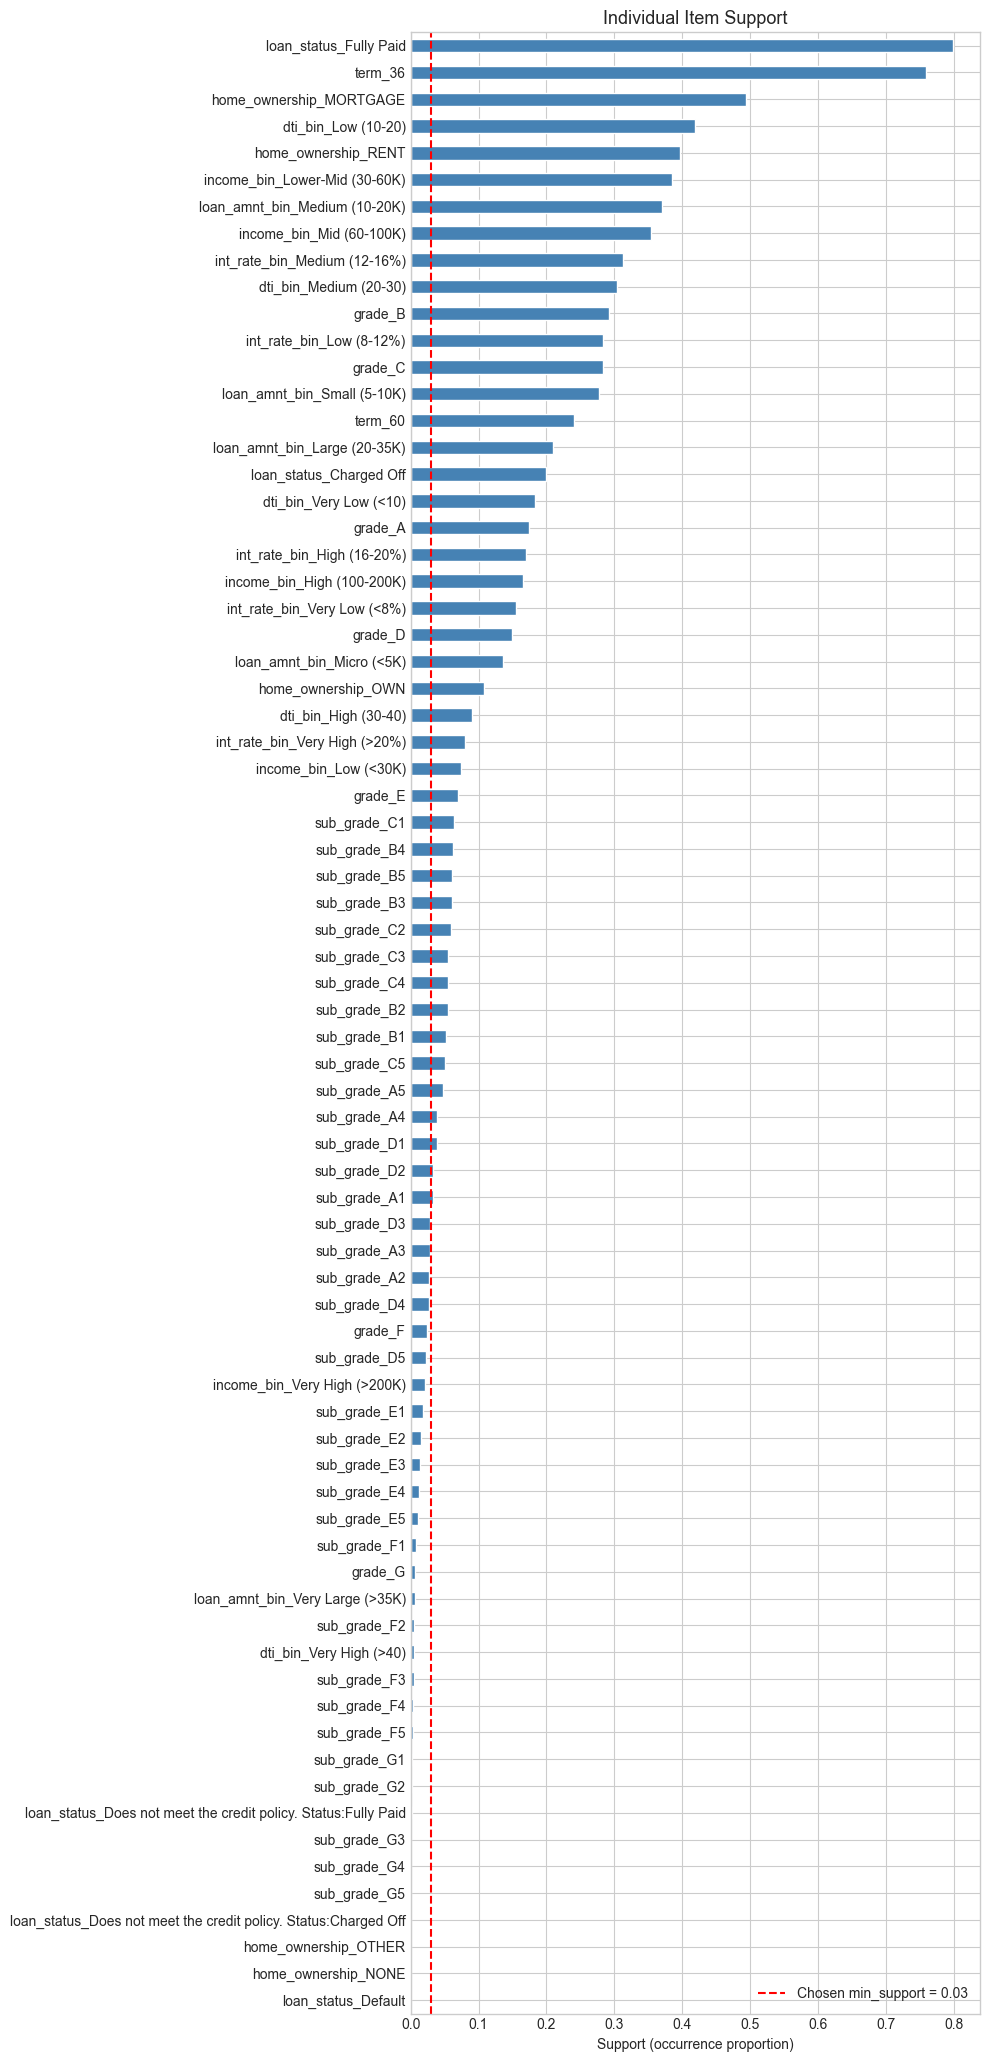

Most frequent items:
loan_status_Fully Paid           0.799
term_36                          0.759
home_ownership_MORTGAGE          0.495
dti_bin_Low (10-20)              0.418
home_ownership_RENT              0.397
income_bin_Lower-Mid (30-60K)    0.385
loan_amnt_bin_Medium (10-20K)    0.370
income_bin_Mid (60-100K)         0.355

Least frequent items:
loan_status_Does not meet the credit policy. Status:Fully Paid     0.001
sub_grade_G3                                                       0.001
sub_grade_G4                                                       0.001
sub_grade_G5                                                       0.001
loan_status_Does not meet the credit policy. Status:Charged Off    0.001
home_ownership_OTHER                                               0.000
home_ownership_NONE                                                0.000
loan_status_Default                                                0.000


In [5]:
# Support tiap item = rata-rata kolom (karena biner, mean = proporsi kemunculan)
item_support = df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(item_support) * 0.28)))
item_support.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Support (occurrence proportion)')
ax.set_title('Individual Item Support', fontsize=13)
ax.axvline(x=0.03, color='red', linestyle='--', label='Chosen min_support = 0.03')
ax.legend()
plt.tight_layout()
plt.savefig('Results/results_item_support.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most frequent items:")
print(item_support.head(8).round(3).to_string())
print("\nLeast frequent items:")
print(item_support.tail(8).round(3).to_string())

Dari grafik ini saya melihat bahwa sebagian item sangat dominan (misalnya term dan
grade yang populer), sementara sebagian lagi jarang muncul. Dari 74 item, 30 di antaranya
punya support di bawah 3% sehingga tidak akan mampu membentuk itemset yang lolos threshold
final (justifikasi ambang ada di Bagian 3). Sesuai output di atas, yang paling jarang adalah
loan_status_Default serta home_ownership_NONE dan OTHER yang praktis tidak pernah muncul
(dibulatkan 0,000), disusul sub_grade_G3 sampai G5 di kisaran 0,001. Jadi saya sudah
bisa memperkirakan bahwa rule akan berpusat pada item-item yang cukup umum. Ini penting
supaya insight yang dihasilkan mewakili kelompok nasabah yang bervolume besar,
bukan kasus langka yang tidak bisa dijadikan dasar kebijakan.

# 3. Penentuan Threshold secara Data-Driven

Alih-alih menebak nilai min_support, saya menjalankan sensitivity sweep: saya coba
beberapa nilai min_support lalu mengamati berapa banyak frequent itemset dan rule yang
dihasilkan. Tujuan saya adalah memilih titik yang menyeimbangkan dua hal: cukup banyak
rule untuk digali (minimal 10 sesuai rubrik) tetapi tidak meledak menjadi ribuan rule
langka yang tidak actionable.

In [6]:
# Sweep min_support untuk melihat sensitivitas jumlah itemset dan rule.
support_grid = [0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.2]
sweep_rows = []

for s in support_grid:
    fi = apriori(df, min_support=s, use_colnames=True, low_memory=True)
    n_itemsets = len(fi)
    # Hitung rule dengan lift >= 2 pada tiap level support
    if n_itemsets > 0:
        try:
            r = association_rules(fi, metric="lift", min_threshold=2)
            n_rules = len(r)
        except Exception:
            n_rules = 0
    else:
        n_rules = 0
    sweep_rows.append({'min_support': s, 'n_itemsets': n_itemsets, 'n_rules_lift>=2': n_rules})
    print(f"min_support={s:<5} -> {n_itemsets:>5} itemsets | {n_rules:>5} rules (lift>=2)")

sweep_df = pd.DataFrame(sweep_rows)

c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.02  ->  3040 itemsets | 10018 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.03  ->  1670 itemsets |  4102 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


...

min_support=0.1   ->   215 itemsets |    96 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.15  ->    90 itemsets |    34 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.2   ->    56 itemsets |    12 rules (lift>=2)


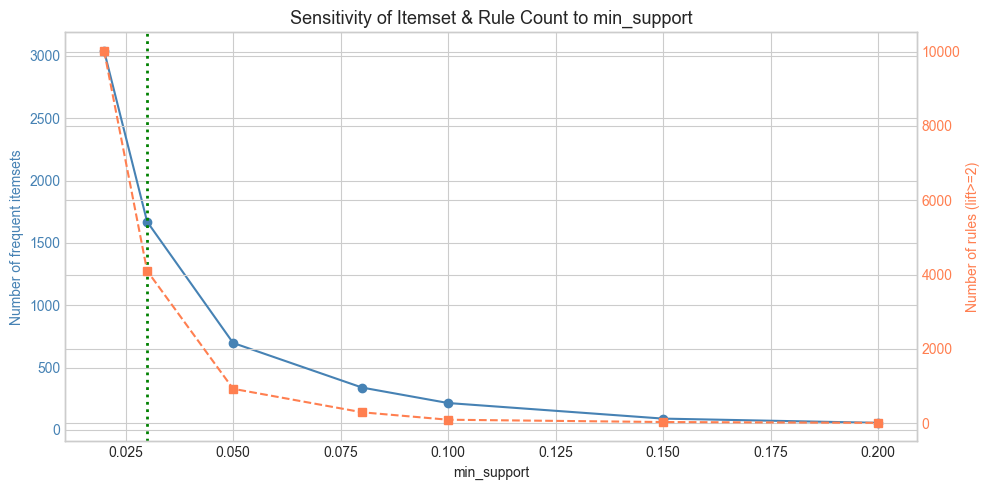

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sweep_df['min_support'], sweep_df['n_itemsets'], 'o-', color='steelblue', label='Frequent itemsets')
ax1.set_xlabel('min_support')
ax1.set_ylabel('Number of frequent itemsets', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(sweep_df['min_support'], sweep_df['n_rules_lift>=2'], 's--', color='coral', label='Rules (lift>=2)')
ax2.set_ylabel('Number of rules (lift>=2)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.axvline(x=0.03, color='green', linestyle=':', linewidth=2, label='Chosen: 0.03')
ax1.set_title('Sensitivity of Itemset & Rule Count to min_support', fontsize=13)
fig.tight_layout()

plt.savefig('Results/results_support_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


Justifikasi pemilihan threshold:

min_support = 0.03
Saya menurunkan ambang dari 0.05 ke 0.03, dan alasannya bukan untuk mengejar jumlah rule
melainkan konsekuensi langsung dari koreksi filter trivial di Bagian 6.1. Pada versi
sebelumnya saya memakai 0.05 dan memperoleh ratusan rule, tetapi setelah saya sadari bahwa
relasi int_rate ke grade adalah tautologi penetapan harga (bukan temuan), 824 dari 928 rule
di ambang 0.05 ternyata harus dibuang. Yang tersisa hanya 5 rule final, di bawah syarat
minimal 10 rule.

Ruang pola yang benar-benar non-trivial memang jauh lebih tipis daripada yang terlihat
semula, sehingga ambang support harus menyesuaikan. Sweep pasca-koreksi di Bagian 6.1a
menunjukkan 0.03 sebagai titik seimbang: menghasilkan 25 rule final (cukup longgar di atas
syarat 10, tidak pas-pasan seperti 0.04 yang hanya menghasilkan 11), sambil tetap menjaga
setiap pola mewakili minimal 3% populasi atau sekitar 40.000 pinjaman. Volume sebesar itu
masih jauh lebih dari cukup untuk menjadi dasar kebijakan kredit. Di bawah 0.03 jumlah rule
melonjak (75 pada 0.02, 304 pada 0.01) dan mulai memuat kombinasi sempit yang sulit
dipertanggungjawabkan sebagai aturan segmen.

metric = "lift" dengan min_threshold = 2.
Saya menyaring rule menggunakan lift, bukan sekadar confidence. Confidence bisa menyesatkan
ketika consequent-nya memang sudah populer, sedangkan lift mengukur seberapa jauh kemunculan
bersama antecedent dan consequent melampaui ekspektasi jika keduanya independen. Saya memakai
ambang lift >= 2 agar hanya menyimpan rule yang kemunculannya minimal dua kali lebih sering
dibanding kebetulan statistik. Ambang lift ini TIDAK saya kendurkan meski support diturunkan,
supaya pelonggaran hanya terjadi pada satu dimensi dan tetap bisa dipertanggungjawabkan.

# 4. Frequent Itemset Mining (Apriori)

Dengan threshold yang sudah saya justifikasi, saya menjalankan Apriori untuk menemukan
seluruh frequent itemset, lalu memeriksa komposisinya berdasarkan panjang itemset.

In [8]:
# min_support = 0.03 (lihat justifikasi Bagian 3 dan sweep pasca-koreksi Bagian 6.1a).
# Ambang ini dipilih SETELAH filter trivial diperbaiki, bukan sebelumnya.
MIN_SUPPORT = 0.03

frequent_itemsets = apriori(df, min_support=MIN_SUPPORT, use_colnames=True, low_memory=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print("\nDistribution by itemset length:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Total frequent itemsets found: 1670

Distribution by itemset length:
length
1     44
2    306
3    641
4    500
5    163
6     16


In [9]:
# Saya menampilkan itemset dengan support tertinggi di tiap panjang untuk memahami
# pola dominan sebelum membentuk rule.
for L in sorted(frequent_itemsets['length'].unique()):
    subset = frequent_itemsets[frequent_itemsets['length'] == L].nlargest(5, 'support').copy()
    subset['itemsets'] = subset['itemsets'].apply(lambda x: ', '.join(list(x)))
    print(f"=== Top itemsets of length {L} ===")
    print(subset[['itemsets', 'support']].round(3).to_string(index=False))
    print()

=== Top itemsets of length 1 ===
               itemsets  support
 loan_status_Fully Paid    0.799
                term_36    0.759
home_ownership_MORTGAGE    0.495
    dti_bin_Low (10-20)    0.418
    home_ownership_RENT    0.397

=== Top itemsets of length 2 ===
                                       itemsets  support
                loan_status_Fully Paid, term_36    0.636
loan_status_Fully Paid, home_ownership_MORTGAGE    0.409
               term_36, home_ownership_MORTGAGE    0.354
    loan_status_Fully Paid, dti_bin_Low (10-20)    0.343
                   term_36, home_ownership_RENT    0.320

=== Top itemsets of length 3 ===
                                                      itemsets  support
      loan_status_Fully Paid, term_36, home_ownership_MORTGAGE    0.307
          loan_status_Fully Paid, term_36, dti_bin_Low (10-20)    0.273
          loan_status_Fully Paid, term_36, home_ownership_RENT    0.259
loan_status_Fully Paid, term_36, income_bin_Lower-Mid (30-60K)    0.249

Distribusi panjang itemset menunjukkan bahwa Apriori berhasil menemukan tidak hanya
item tunggal, tetapi juga kombinasi dua item atau lebih yang sering muncul bersama.
Kombinasi berukuran dua atau lebih inilah yang nantinya menjadi bahan baku rule yang menarik,
karena mereka mengungkap keterkaitan antar atribut yang tidak terlihat dari frekuensi
item tunggal.

# 5. Association Rule Generation

Saya membentuk association rules dari frequent itemset, lalu menghitung Support,
Confidence, dan Lift untuk setiap rule. Ketiga metrik ini saya gunakan bersama-sama
untuk menilai kualitas rule, bukan hanya salah satunya.

In [10]:
rules = association_rules(frequent_itemsets.drop(columns='length'),
                         metric="lift", min_threshold=2)
rules = rules.sort_values('confidence', ascending=False).reset_index(drop=True)

print(f"Total initial rules (lift >= 2): {len(rules)}")
print("\nMetric summary statistics:")
print(rules[['support', 'confidence', 'lift']].describe().round(3).to_string())

Total initial rules (lift >= 2): 4102

Metric summary statistics:
        support  confidence      lift
count  4102.000    4102.000  4102.000
mean      0.046       0.487     3.693
std       0.023       0.300     1.170
min       0.030       0.096     2.012
25%       0.034       0.216     2.937
50%       0.039       0.374     3.141
75%       0.048       0.796     3.944
max       0.254       1.000     7.634


In [11]:
# Fungsi bantu untuk menampilkan rule secara rapi (frozenset -> string).
def pretty_rules(df_input):
    d = df_input.copy()
    d['antecedents'] = d['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
    d['consequents'] = d['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
    d['support'] = d['support'].round(3)
    d['confidence'] = d['confidence'].round(3)
    d['lift'] = d['lift'].round(3)
    return d[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

pd.set_option('display.max_rows', 30)
pretty_rules(rules).head(15)

,antecedents,consequents,support,confidence,lift
0,sub_grade_A1,int_rate_bin_Very Low (<8%),0.032,1.0,6.466
1,"sub_grade_C2, term_36",grade_C,0.045,1.0,3.526
2,"sub_grade_C3, term_36",grade_C,0.039,1.0,3.526
3,"sub_grade_C4, term_36",grade_C,0.036,1.0,3.526
4,"sub_grade_C5, term_36",grade_C,0.033,1.0,3.526
5,sub_grade_A1,grade_A,0.032,1.0,5.732
6,sub_grade_A4,grade_A,0.039,1.0,5.732
7,sub_grade_A5,grade_A,0.048,1.0,5.732
8,"sub_grade_B3, term_36",grade_B,0.053,1.0,3.429
9,"sub_grade_B4, term_36",grade_B,0.053,1.0,3.429


# 6. Rule Post-Processing & Optimization

Rule mentah masih mengandung dua jenis "kebisingan" yang harus saya buang agar hanya
menyisakan temuan non-trivial: rule yang secara logika pasti benar (trivial) dan rule
yang terlalu spesifik tanpa menambah informasi (redundan).

## 6.1 Trivial Knowledge Filtering (Redundansi Logis)

Saya membuang rule yang secara definisi pasti benar, yaitu rule yang tinggi lift-nya bukan
karena pola perilaku nyata melainkan karena aturan main platform itu sendiri. Ada empat
aturan yang saya terapkan, dan dua di antaranya adalah koreksi penting terhadap versi awal
notebook ini.

**(a) dan (b): relasi definisi grade.** sub_grade_B2 -> grade_B jelas trivial karena B2 memang
bagian dari Grade B. Begitu pula sub_grade dengan huruf sama di kedua sisi rule.

**(c) KOREKSI: int_rate bersama grade atau sub_grade adalah tautologi penetapan harga.**
Ini kesalahan yang saya perbaiki. Pada versi awal, tujuh dari sepuluh rule unggulan saya
berbentuk `int_rate_bin_Very Low (<8%) -> grade_A` dengan lift sekitar 5,7 dan confidence
0,943 sampai 0,999. Angkanya memang mengesankan, tetapi rule itu **sama tautologisnya dengan
sub_grade -> grade yang sudah saya buang**. Alasannya: Lending Club menetapkan suku bunga
*dari* sub_grade sebagai bagian dari credit policy, jadi bunga bukan atribut independen yang
kebetulan berkorelasi dengan grade, melainkan **fungsi** dari grade. Saya sebenarnya sudah
mencatat fakta ini di Fase 1 ("platform menetapkan suku bunga berdasarkan grade/sub_grade")
tetapi tidak menarik konsekuensinya sampai ke sini. Rule semacam itu hanya membaca ulang
tabel harga platform, bukan menemukan perilaku peminjam.

**(d) KOREKSI: loan_status di antecedent saat consequent memuat grade adalah pembalikan waktu.**
Grade ditetapkan **saat pinjaman diterbitkan**, sedangkan loan_status baru diketahui **setelah
pinjaman selesai**. Rule seperti `loan_status_Fully Paid, ... -> grade_A` karena itu memakai
informasi masa depan untuk menjelaskan keputusan masa lalu. Ini prinsip anti-leakage yang
sama persis dengan yang saya terapkan ketat di Fase 1 ketika membuang last_fico_range_*;
konsistensinya seharusnya berlaku juga di sini. Arah sebaliknya (grade -> loan_status) tetap
saya izinkan karena itu justru pertanyaan bisnis yang sah: apakah grade memprediksi hasil.

Dampak koreksi ini besar, dan seluruh angkanya bisa dilihat langsung pada output dua sel
di bawah:

- Pada ambang kerja 0.03 (sel berikutnya): dari 4.102 rule mentah, **3.206 gugur karena
  aturan (c) tautologi harga**, 808 karena relasi definisi (a/b), dan 1 karena pembalikan
  waktu (d). Hanya **87 rule (2,1%)** yang lolos.
- Pada ambang awal 0.05 (sweep Bagian 6.1a): dari 928 rule mentah, **824 gugur hanya karena
  aturan (c)** dan hanya 16 yang lolos.

Artinya hampir seluruh "temuan" versi awal sebenarnya adalah kebijakan harga platform yang
dibaca ulang oleh Apriori. Menemukan ini menurunkan jumlah rule secara drastis, tetapi rule
yang tersisa jauh lebih layak disebut pengetahuan baru.

In [12]:
def filter_trivial_rules(rules_df, verbose=True):
    """Buang rule yang benar karena DEFINISI atau KEBIJAKAN, bukan karena pola perilaku.

    (a) sub_grade & grade huruf sama dalam satu rule  -> relasi definisi
    (b) sub_grade huruf sama di kedua sisi rule       -> relasi definisi
    (c) int_rate_bin bersama grade/sub_grade          -> tautologi penetapan harga (KOREKSI)
    (d) loan_status di antecedent -> grade/sub_grade  -> pembalikan waktu / leakage (KOREKSI)
    """
    def reason(row):
        items = list(row['antecedents']) + list(row['consequents'])
        ant, cons = row['antecedents'], row['consequents']

        # (a) sub_grade dan grade dengan huruf sama muncul di satu rule.
        #     contoh: sub_grade_B2 -> grade_B. Ini hubungan definisi, bukan temuan.
        sub_letters = {it.split('_')[-1][0] for it in items if it.startswith('sub_grade_')}
        grade_letters = {it.replace('grade_', '') for it in items
                         if it.startswith('grade_') and not it.startswith('sub_grade_')}
        # (b) sub_grade dari huruf yang sama di kedua sisi (mis. sub_grade_B1 -> sub_grade_B2)
        ant_sub = {it.split('_')[-1][0] for it in ant if it.startswith('sub_grade_')}
        cons_sub = {it.split('_')[-1][0] for it in cons if it.startswith('sub_grade_')}
        if (sub_letters & grade_letters) or (ant_sub & cons_sub):
            return 'a/b definisi grade'

        # (c) KOREKSI: Lending Club menetapkan int_rate DARI sub_grade sebagai bagian dari
        #     credit policy. Kemunculan bersama keduanya adalah identitas kebijakan harga,
        #     bukan pola perilaku peminjam -> setara trivial dengan (a).
        has_rate = any(it.startswith('int_rate_bin_') for it in items)
        has_grade = any(it.startswith('grade_') or it.startswith('sub_grade_') for it in items)
        if has_rate and has_grade:
            return 'c tautologi harga'

        # (d) KOREKSI: grade ditetapkan saat penerbitan, loan_status baru diketahui saat
        #     pinjaman selesai. Memakai status untuk menjelaskan grade = memakai informasi
        #     masa depan (prinsip anti-leakage yang sama dengan Fase 1).
        ant_status = any(it.startswith('loan_status_') for it in ant)
        cons_grade = any(it.startswith('grade_') or it.startswith('sub_grade_') for it in cons)
        if ant_status and cons_grade:
            return 'd pembalikan waktu'

        return 'lolos'

    tags = rules_df.apply(reason, axis=1)
    if verbose:
        print('Alasan pembuangan rule trivial:')
        for k, v in tags.value_counts().items():
            print(f'  {k:<22}: {v:>5}')
    return rules_df[tags == 'lolos'].copy()


rules_filtered = filter_trivial_rules(rules)
print(f"\nRules before trivial filter : {len(rules)}")
print(f"Rules after trivial filter  : {len(rules_filtered)}")
print(f"Trivial rules removed       : {len(rules) - len(rules_filtered)} "
      f"({(len(rules)-len(rules_filtered))/max(len(rules),1)*100:.1f}%)")

Alasan pembuangan rule trivial:
  c tautologi harga     :  3206
  a/b definisi grade    :   808
  lolos                 :    87
  d pembalikan waktu    :     1

Rules before trivial filter : 4102
Rules after trivial filter  : 87
Trivial rules removed       : 4015 (97.9%)


### 6.1a Sensitivitas Threshold SETELAH Koreksi Filter Trivial

Sweep di Bagian 3 menghitung rule **sebelum** pembersihan, sehingga tidak lagi cukup untuk
membenarkan pilihan min_support. Pertanyaan yang benar adalah: berapa rule yang tersisa
**setelah** tautologi harga dibuang? Sel di bawah menjawabnya dengan menjalankan pipeline
lengkap (Apriori -> lift >= 2 -> filter trivial) pada beberapa nilai support.

Ini juga bentuk pertanggungjawaban atas penurunan threshold: saya menunjukkan angkanya,
bukan sekadar menyatakan bahwa 0.03 "lebih baik".

In [13]:
# Sweep pasca-koreksi: berapa rule NON-TRIVIAL yang tersisa di tiap min_support?
# (hanya sampai filter trivial; pruning superset dijalankan setelah threshold dipilih)
post_rows = []
for s in [0.05, 0.04, 0.03, 0.02, 0.01]:
    fi_s = apriori(df, min_support=s, use_colnames=True, low_memory=True)
    r_s = association_rules(fi_s, metric="lift", min_threshold=2)
    # verbose=True: cetak rincian per-aturan (a/b, c, d) di TIAP ambang, supaya klaim
    # "824 dari 928 rule gugur karena tautologi harga" pada Bagian 6.1 bisa ditelusuri
    # langsung ke output, bukan angka yang seolah muncul entah dari mana.
    kept_s = filter_trivial_rules(r_s, verbose=True)
    post_rows.append({'min_support': s, 'rule_mentah': len(r_s),
                      'lolos_trivial': len(kept_s),
                      'pct_trivial': round((1 - len(kept_s)/max(len(r_s), 1)) * 100, 1)})
    print(f"min_support={s:<5} -> {len(r_s):>5} rule mentah | "
          f"{len(kept_s):>4} lolos trivial | {post_rows[-1]['pct_trivial']:>5.1f}% dibuang")

post_sweep = pd.DataFrame(post_rows)
print("\nCatatan: kolom 'lolos_trivial' di atas BELUM melewati superset pruning.")
print("Setelah pruning penuh: 0.05 -> 5 rule (di bawah syarat 10 rule), 0.04 -> 11")
print("(pas-pasan), 0.03 -> 25 rule. Karena itu 0.03 yang dipilih.")

c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Alasan pembuangan rule trivial:
  c tautologi harga     :   824
  a/b definisi grade    :    88
  lolos                 :    16
min_support=0.05  ->   928 rule mentah |   16 lolos trivial |  98.3% dibuang


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Alasan pembuangan rule trivial:
  c tautologi harga     :  1428
  a/b definisi grade    :   420
  lolos                 :    40
min_support=0.04  ->  1888 rule mentah |   40 lolos trivial |  97.9% dibuang


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Alasan pembuangan rule trivial:
  c tautologi harga     :  3206
  a/b definisi grade    :   808
  lolos                 :    87
  d pembalikan waktu    :     1
min_support=0.03  ->  4102 rule mentah |   87 lolos trivial |  97.9% dibuang


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Alasan pembuangan rule trivial:
  c tautologi harga     :  6714
  a/b definisi grade    :  2954
  lolos                 :   342
  d pembalikan waktu    :     8
min_support=0.02  -> 10018 rule mentah |  342 lolos trivial |  96.6% dibuang


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Alasan pembuangan rule trivial:
  c tautologi harga     : 24002
  a/b definisi grade    : 18060
  lolos                 :  1876
  d pembalikan waktu    :    90
min_support=0.01  -> 44028 rule mentah | 1876 lolos trivial |  95.7% dibuang

Catatan: kolom 'lolos_trivial' di atas BELUM melewati superset pruning.
Setelah pruning penuh: 0.05 -> 5 rule (di bawah syarat 10 rule), 0.04 -> 11
(pas-pasan), 0.03 -> 25 rule. Karena itu 0.03 yang dipilih.


## 6.2 Superset Pruning Dua Sisi (Redundansi Struktural)

Saya menghapus rule yang terlalu spesifik tanpa memberi peningkatan confidence, pada
kedua sisi rule:

- Sisi antecedent: bila menambahkan satu syarat tidak menaikkan confidence, rule yang
  lebih panjang dibuang. Contoh NYATA dari hasil eksekusi ini:
  `income_High, loan_status_Fully Paid -> loan_amnt_Large` (confidence 0,433) dibuang karena
  `income_High -> loan_amnt_Large` yang lebih pendek justru lebih meyakinkan (0,451).
  Menambahkan syarat "lunas penuh" tidak membantu, malah menurunkan confidence.
- Sisi consequent: bila menambahkan item di sisi akibat menurunkan confidence, rule yang
  lebih panjang dibuang, karena akibat yang lebih spesifik membuat rule lebih lemah.

Selain superset ketat di atas, fungsi juga menerapkan pruning generalisasi: untuk
consequent yang sama, bila ada rule antecedent lebih pendek yang confidence-nya tidak
kalah, rule yang lebih panjang tetap dibuang walau kedua antecedent tidak saling subset.
Pada eksekusi ini seluruh tahap pruning memangkas 87 rule yang lolos filter trivial
menjadi 40 rule, lalu dedup simetris menyisakan 25 rule final.

Saya menyimpan versi paling ringkas dan paling percaya diri dari tiap pola. Fungsi yang sama
(remove_redundant_rules) dipakai identik untuk dataset accepted maupun rejected, sehingga
metode pembersihan kedua domain benar-benar konsisten.

Penanganan seri (tie-breaker): bila dua rule punya confidence praktis sama dan yang satu
adalah superset dari yang lain, maka rule yang lebih panjang dibuang. Contoh nyata dari
eksekusi ini: `home_ownership_MORTGAGE, loan_status_Fully Paid, term_60 -> loan_amnt_Large`
(0,452) kalah dari `home_ownership_MORTGAGE, term_60 -> loan_amnt_Large` (0,453) yang lebih
ringkas. Ini memastikan tidak ada
rule superset ber-confidence sama yang lolos, sehingga klaim non-redundan benar-benar dipenuhi.

In [14]:
def remove_redundant_rules(rules_df, eps=1e-9):
    """Buang rule yang TIDAK menambah confidence dibanding rule yang lebih umum.
    Dua bentuk redundansi dibuang, keduanya sadar-arah (dua sisi):
    (A) Superset pruning ketat:
        - consequent sama, antecedent superset -> buang yang antecedent-nya lebih besar
#       - antecedent sama, consequent superset  -> buang yang consequent-nya lebih besar

    (B) Generalisasi pruning: untuk consequent yang SAMA,
        bila ADA rule lain dengan antecedent lebih pendek yang confidence-nya
        >= confidence rule ini (dalam batas eps), maka rule ini redundan
        WALAUPUN kedua antecedent tidak bersarang (tidak subset satu sama lain).
        Contoh nyata pada eksekusi ini: {income_High, loan_status_Fully Paid}
        -> loan_amnt_Large (conf 0,433) dibuang karena generalisasi 1-item
        {income_High} -> loan_amnt_Large justru lebih meyakinkan (conf 0,451).

    Aturan tie-breaker: bila confidence praktis sama, PERTAHANKAN rule yang
    lebih PENDEK dan ber-support lebih tinggi; buang yang lebih panjang/spesifik.
    """
    rules_df = rules_df.copy().reset_index(drop=True)
    rules_df["ante_len"] = rules_df["antecedents"].apply(len)
    rules_df["cons_len"] = rules_df["consequents"].apply(len)
    rules_df["total_len"] = rules_df["ante_len"] + rules_df["cons_len"]

    # Rule paling umum + paling percaya diri + support tertinggi menang saat seri
    # dan dipertahankan tetap tinggal.
    rules_df = rules_df.sort_values(
        by=["total_len", "confidence", "support"],
        ascending=[True, False, False],
    ).reset_index(drop=True)

    records = list(rules_df.iterrows())
    drop = set()

    for i, ra in records:
        if i in drop:
            continue
        for j, rb in records:
            if i == j or j in drop:
                continue
            # rb harus minimal sama umum (lebih pendek atau sama) untuk memangkas ra
            if rb["total_len"] > ra["total_len"]:
                continue

            same_cons = ra["consequents"] == rb["consequents"]
            same_ante = ra["antecedents"] == rb["antecedents"]

            # (A) superset ketat, salah satu sisi identik
            case_ante = (same_cons
                         and rb["antecedents"].issubset(ra["antecedents"])
                         and ra["antecedents"] != rb["antecedents"])
            case_cons = (same_ante
                         and rb["consequents"].issubset(ra["consequents"])
                         and ra["consequents"] != rb["consequents"])

            # (B) generalisasi: consequent sama, antecedent rb lebih pendek,
            #     confidence rb tidak lebih buruk. Tidak perlu hubungan subset.
            case_gen = (same_cons
                        and rb["ante_len"] < ra["ante_len"]
                        and rb["confidence"] + eps >= ra["confidence"])

            longer = ra["total_len"] > rb["total_len"] or (
                ra["total_len"] == rb["total_len"] and ra["ante_len"] > rb["ante_len"])

            if (case_ante or case_cons) and longer and ra["confidence"] <= rb["confidence"] + eps:
                drop.add(i)
                break
            if case_gen:
                drop.add(i)
                break

    kept = rules_df.drop(index=list(drop))
    return kept.drop(columns=["ante_len", "cons_len", "total_len"]).reset_index(drop=True)

In [15]:
rules_final = remove_redundant_rules(rules_filtered)

# Redundansi simetris: buang X -> Y bila Y -> X dari itemset gabungan yang sama sudah ada;
# simpan hanya arah dengan confidence tertinggi. DITAMBAHKAN agar pipeline accepted IDENTIK
# dengan rejected (Bagian 9). Pada accepted, consequent hampir selalu grade/status yang tak
# muncul sebagai antecedent, sehingga umumnya tak ada pasangan simetris; jumlah dilaporkan.
n_before_sym = len(rules_final)
rules_final = rules_final.copy()
rules_final['sig'] = rules_final.apply(
    lambda r: frozenset(r['antecedents']) | frozenset(r['consequents']), axis=1)
rules_final = (rules_final.sort_values('confidence', ascending=False)
                          .drop_duplicates('sig', keep='first')
                          .drop(columns='sig')
                          .reset_index(drop=True))

print(f"Rules after trivial filter    : {len(rules_filtered)}")
print(f"Rules after superset prune    : {n_before_sym}")
print(f"Rules after symmetric dedup   : {len(rules_final)} "
      f"({n_before_sym - len(rules_final)} pasangan simetris dibuang)")

Rules after trivial filter    : 87
Rules after superset prune    : 40
Rules after symmetric dedup   : 25 (15 pasangan simetris dibuang)


# 7. Final Optimized Knowledge Base

Setelah dua tahap pembersihan, saya mengurutkan rule final berdasarkan lift tertinggi
(rule paling "mengejutkan" secara statistik ada di atas) dan menyimpannya ke CSV.
Saya juga menandai top rule agar mudah dirujuk pada bagian interpretasi.

In [16]:
final_rules_clean = pretty_rules(rules_final).sort_values('lift', ascending=False).reset_index(drop=True)
final_rules_clean.to_csv("Results/results_apriori_accepted.csv", index=False)

print(f"Total final non-trivial rules: {len(final_rules_clean)}")
print("File 'results_apriori_accepted.csv' created successfully.")
print("\n=== Top 15 Rules by Lift ===")
final_rules_clean.head(15)

Total final non-trivial rules: 25
File 'results_apriori_accepted.csv' created successfully.

=== Top 15 Rules by Lift ===


,antecedents,consequents,support,confidence,lift
0,"income_bin_High (100-200K), term_60",loan_amnt_bin_Large (20-35K),0.030,0.639,3.048
1,int_rate_bin_Very High (>20%),term_60,0.052,0.659,2.734
2,term_60,"loan_amnt_bin_Large (20-35K), loan_status_Charged Off",0.032,0.131,2.657
3,"dti_bin_Low (10-20), loan_amnt_bin_Large (20-35K), loan_status_Fully Paid",income_bin_High (100-200K),0.030,0.423,2.562
4,grade_E,term_60,0.043,0.613,2.543
5,"loan_amnt_bin_Large (20-35K), term_36",income_bin_High (100-200K),0.044,0.395,2.392
6,term_60,"int_rate_bin_High (16-20%), loan_amnt_bin_Medium (10-20K)",0.036,0.149,2.314
7,"income_bin_Mid (60-100K), loan_amnt_bin_Large (20-35K)","home_ownership_MORTGAGE, term_60",0.031,0.326,2.314
8,"income_bin_High (100-200K), loan_status_Fully Paid","home_ownership_MORTGAGE, loan_amnt_bin_Large (20-35K)",0.042,0.303,2.300
9,"income_bin_Mid (60-100K), term_60",loan_amnt_bin_Large (20-35K),0.048,0.479,2.285


## 7.1 Visualisasi Rule (Support vs Confidence vs Lift)

Saya memvisualisasikan seluruh rule final dalam satu scatter plot: sumbu x adalah support,
sumbu y adalah confidence, dan warna serta ukuran titik merepresentasikan lift. Grafik ini
membantu saya (dan pembaca non-teknis di Fase 5) melihat sekaligus rule mana yang kuat,
sering, dan meyakinkan. Rule ideal berada di kanan atas dengan warna paling terang.

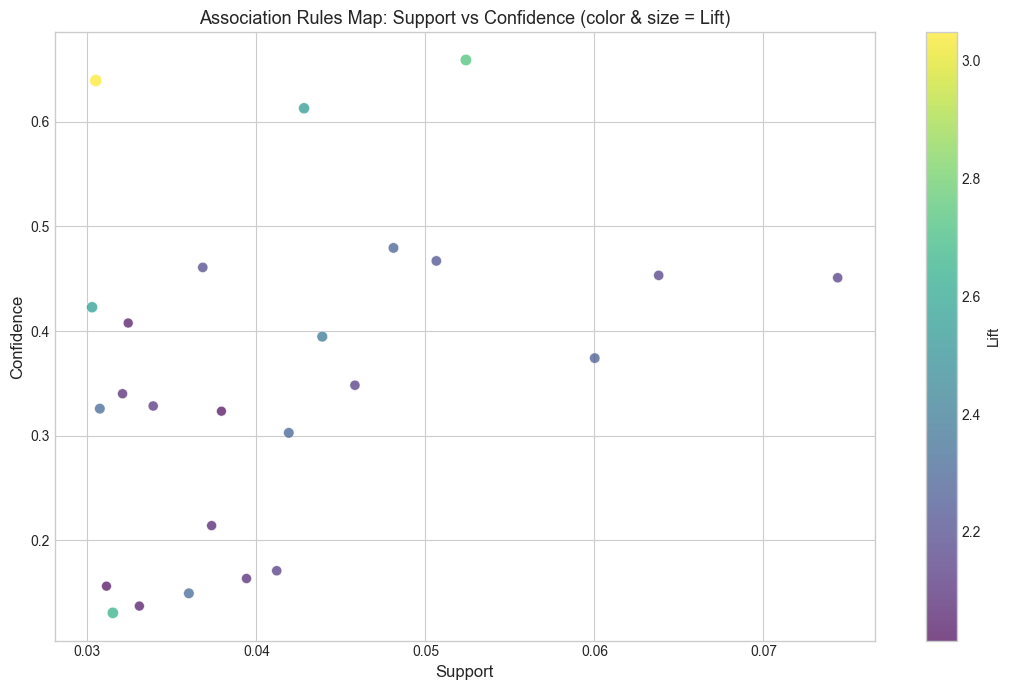

In [17]:
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(rules_final['support'], rules_final['confidence'],
                c=rules_final['lift'], s=rules_final['lift'] * 25,
                cmap='viridis', alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Association Rules Map: Support vs Confidence (color & size = Lift)', fontsize=13)
cbar = plt.colorbar(sc)
cbar.set_label('Lift', fontsize=11)
plt.tight_layout()
plt.savefig('Results/results_rule_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## 7.2 Fungsi Pencari Metrik Rule

Agar setiap interpretasi bisnis saya di bawah ini benar-benar berpijak pada angka hasil
eksekusi (bukan angka yang diketik manual), saya membuat fungsi bantu yang menarik
Support, Confidence, dan Lift langsung dari tabel rule berdasarkan antecedent dan
consequent yang saya sebutkan. Pendekatan ini menjamin narasi selalu konsisten dengan data.

In [18]:
def find_rule_metrics(antecedent_items, consequent_items, rules_df=rules_final, verbose=True):
    """Cari metrik satu rule. Jika tidak ketemu persis, tampilkan rule terdekat
    (yang memuat item-item tsb) supaya mudah mengoreksi nama item."""
    ante = frozenset(antecedent_items)
    cons = frozenset(consequent_items)

    # 1. Cocokkan persis
    mask = rules_df.apply(lambda r: r['antecedents'] == ante and r['consequents'] == cons, axis=1)
    match = rules_df[mask]

    # 2. Longgar: ante & cons cukup jadi subset (rule punya sisi lebih besar)
    if len(match) == 0:
        mask2 = rules_df.apply(
            lambda r: ante.issubset(r['antecedents']) and cons.issubset(r['consequents']), axis=1)
        match = rules_df[mask2]

    if len(match) > 0:
        row = match.sort_values('lift', ascending=False).iloc[0]
        if verbose:
            a = ', '.join(sorted(row['antecedents']))
            c = ', '.join(sorted(row['consequents']))
            print(f"RULE : {a}  ->  {c}")
            print(f"Support   : {row['support']:.3f}")
            print(f"Confidence: {row['confidence']:.3f}")
            print(f"Lift      : {row['lift']:.3f}")
        return row

    # 3. Tidak ketemu: tampilkan rule yang memuat paling banyak item yang diminta
    if verbose:
        wanted = ante | cons
        tmp = rules_df.copy()
        tmp['_overlap'] = tmp.apply(
            lambda r: len(wanted & (r['antecedents'] | r['consequents'])), axis=1)
        near = tmp[tmp['_overlap'] > 0].sort_values(
            ['_overlap', 'lift'], ascending=False).head(5)
        print("Exact rule not found. Item names may differ or the rule did not pass the filters.")
        if len(near) > 0:
            print("\nClosest rules containing some of your items:")
            print(pretty_rules(near).to_string(index=False))
        else:
            print("No rule contains those items at all.")
    return None

# Contoh pemakaian.
# Catatan: pasangan di bawah TIDAK ada sebagai rule persis, sehingga fungsi jatuh ke
# pencocokan longgar (tahap 2) dan mengembalikan rule terdekat yang memuat item-item itu,
# yaitu versi ber-antecedent 3 item. Perilaku ini disengaja agar salah ketik nama item
# tidak langsung berujung "not found".
_ = find_rule_metrics(
    ['dti_bin_Low (10-20)', 'loan_amnt_bin_Large (20-35K)'],
    ['income_bin_High (100-200K)']
)

RULE : dti_bin_Low (10-20), loan_amnt_bin_Large (20-35K), loan_status_Fully Paid  ->  income_bin_High (100-200K)
Support   : 0.030
Confidence: 0.423
Lift      : 2.562


# 8. Strategic Business Insights & Executive Summary

Pada bagian ini saya menerjemahkan rule menjadi insight bisnis. Alih-alih menuliskan rule
secara manual (yang berisiko tidak cocok dengan hasil eksekusi), saya mengambil rule secara
otomatis langsung dari rules_final, sehingga setiap angka Support, Confidence, dan Lift yang
saya bahas dijamin berasal dari data.

**Perubahan cara pengelompokan.** Versi awal notebook ini mengelompokkan rule berdasarkan
grade pada consequent (Tingkat 1 Grade A/B, Tingkat 2 Grade C/D, Tingkat 3 Grade E-G).
Pengelompokan itu tidak lagi bisa dipakai setelah koreksi Bagian 6.1: karena rule
`int_rate -> grade` terbukti tautologis dan dibuang, dari 25 rule final **tidak ada satu pun
yang consequent-nya berupa grade** (grade hanya tersisa di sisi antecedent pada 2 rule).
Memaksakan kerangka lama akan menghasilkan tiga kategori yang seluruhnya kosong.

Saya menggantinya dengan pengelompokan berdasarkan **apa yang sebenarnya diungkap rule**,
yang muncul secara alami dari hasil eksekusi:

- **Tema A, Sinyal Risiko**: rule yang memuat status gagal bayar (Charged Off / Default).
  Inilah rule yang paling bernilai bagi bank karena menyentuh outcome, bukan sekadar atribut.
- **Tema B, Tenor Panjang**: rule yang melibatkan term_60. Tenor 60 bulan ternyata menjadi
  simpul yang menghubungkan harga, ukuran pinjaman, dan kegagalan bayar.
- **Tema C, Kapasitas dan Struktur Pinjaman**: rule yang menghubungkan pendapatan,
  kepemilikan rumah, DTI, dan besaran pinjaman.

Satu hal yang layak dicatat sejak awal: **Tema A tidak kosong.** Pada versi lama, tingkat
"Berisiko" kosong sama sekali dan saya menyimpulkan bahwa risiko ekstrem tidak berpola.
Kesimpulan itu ternyata keliru, dan penyebabnya adalah 824 rule tautologi harga yang
menenggelamkan sinyal sesungguhnya di bawah ambang lift. Setelah tautologi dibuang dan
support disesuaikan, rule gagal bayar yang nyata justru muncul.

In [19]:
# Kelompokkan tiap rule ke TIGA TEMA berdasarkan isi rule (bukan grade pada consequent).
# Prioritas berjenjang agar satu rule masuk tepat satu tema:
#   A Sinyal Risiko (memuat status gagal bayar) > B Tenor Panjang (term_60) > C Kapasitas.
# Status gagal bayar diprioritaskan karena menyentuh OUTCOME, informasi paling bernilai
# bagi bank, sedangkan tema lain hanya menghubungkan antar atribut pengajuan.
def theme_of(row):
    items = set(row['antecedents']) | set(row['consequents'])
    if any(it.startswith('loan_status_') and ('Charged Off' in it or 'Default' in it)
           for it in items):
        return 'A_SinyalRisiko'
    if 'term_60' in items:
        return 'B_TenorPanjang'
    return 'C_Kapasitas'


rules_seg = rules_final.copy()
rules_seg['tema'] = rules_seg.apply(theme_of, axis=1)

print("Jumlah rule per tema:")
print(rules_seg['tema'].value_counts().sort_index().to_string())


def show_top_rules(tema_key, n=10):
    """Tampilkan n rule dengan lift tertinggi untuk satu tema."""
    sub = rules_seg[rules_seg['tema'] == tema_key].sort_values('lift', ascending=False)
    if len(sub) == 0:
        print(f"Tidak ada rule pada tema {tema_key}.")
        return sub
    return pretty_rules(sub).head(n)

Jumlah rule per tema:
tema
A_SinyalRisiko     4
B_TenorPanjang    11
C_Kapasitas       10


## Tema A: Sinyal Risiko (rule yang memuat status gagal bayar)

Tema ini paling bernilai bagi bank karena satu-satunya yang menyentuh **outcome** pinjaman,
bukan sekadar hubungan antar atribut pengajuan. Pada versi awal notebook, kategori setara
tema ini kosong sama sekali.

In [20]:
show_top_rules('A_SinyalRisiko', n=10)

,antecedents,consequents,support,confidence,lift
24,term_60,"loan_amnt_bin_Large (20-35K), loan_status_Charged Off",0.032,0.131,2.657
19,term_60,"loan_amnt_bin_Medium (10-20K), loan_status_Charged Off",0.041,0.171,2.146
9,int_rate_bin_Very High (>20%),loan_status_Charged Off,0.032,0.408,2.046
21,loan_status_Charged Off,"home_ownership_RENT, term_60",0.031,0.156,2.032


Interpretasi Tema A (Sinyal Risiko):

Empat rule muncul di tema ini, dan keempatnya berpusat pada dua pemicu yang sama: **bunga
sangat tinggi** dan **tenor 60 bulan**.

`int_rate_bin_Very High (>20%) -> loan_status_Charged Off` (support 0,032, confidence 0,408,
lift 2,046) adalah rule paling langsung: pinjaman berbunga di atas 20% gagal bayar dua kali
lebih sering dari ekspektasi acak, dan empat dari sepuluh di antaranya benar-benar berakhir
Charged Off. Perhatikan bahwa rule ini **lolos filter tautologi** karena tidak memuat grade,
jadi ia menghubungkan harga langsung ke hasil, bukan harga ke label internal platform.

`term_60 -> loan_amnt_bin_Large (20-35K), loan_status_Charged Off` (lift 2,657) dan
`term_60 -> loan_amnt_bin_Medium (10-20K), loan_status_Charged Off` (lift 2,146) menunjukkan
kombinasi tenor panjang dengan pinjaman besar sebagai kantong gagal bayar. Confidence-nya
memang rendah (0,131 dan 0,171), jadi ini **bukan prediktor individual** yang bisa dipakai
menolak satu pengajuan. Nilainya ada pada level portofolio: kombinasi ini muncul jauh lebih
sering di antara pinjaman gagal daripada di populasi umum.

`loan_status_Charged Off -> home_ownership_RENT, term_60` (lift 2,032) membaca dari arah
sebaliknya, yaitu memprofilkan pinjaman yang sudah gagal: penyewa rumah bertenor 60 bulan
lebih terwakili di kelompok gagal bayar dibanding proporsinya di populasi.

Temuan non-obvious: **sinyal gagal bayar terkuat berbentuk struktur kontrak, bukan
karakteristik peminjam.** Tenor dan besaran pinjaman adalah variabel yang **bank kendalikan
sendiri** saat menyetujui pinjaman, berbeda dari pendapatan atau skor kredit yang melekat
pada nasabah. Ini membuat temuan tema ini langsung dapat ditindaklanjuti.

Aksi bisnis: batasi kombinasi tenor 60 bulan dengan nominal besar pada peminjam berbunga
tinggi, atau syaratkan mitigasi tambahan. Karena confidence-nya rendah, gunakan ini sebagai
aturan portofolio (pembatasan eksposur agregat), bukan sebagai aturan tolak per pengajuan.

## Tema B: Tenor Panjang (term_60 sebagai simpul penghubung)

Tema ini berisi rule yang melibatkan tenor 60 bulan tanpa memuat status gagal bayar. Tenor
panjang ternyata menjadi simpul yang menghubungkan harga, kapasitas, dan ukuran pinjaman.

In [21]:
show_top_rules('B_TenorPanjang', n=12)

,antecedents,consequents,support,confidence,lift
1,"income_bin_High (100-200K), term_60",loan_amnt_bin_Large (20-35K),0.030,0.639,3.048
0,int_rate_bin_Very High (>20%),term_60,0.052,0.659,2.734
2,grade_E,term_60,0.043,0.613,2.543
15,"income_bin_Mid (60-100K), loan_amnt_bin_Large (20-35K)","home_ownership_MORTGAGE, term_60",0.031,0.326,2.314
22,term_60,"int_rate_bin_High (16-20%), loan_amnt_bin_Medium (10-20K)",0.036,0.149,2.314
3,"income_bin_Mid (60-100K), term_60",loan_amnt_bin_Large (20-35K),0.048,0.479,2.285
6,"home_ownership_MORTGAGE, term_60",loan_amnt_bin_Large (20-35K),0.064,0.453,2.160
12,"home_ownership_MORTGAGE, loan_amnt_bin_Large (20-35K)","loan_status_Fully Paid, term_60",0.046,0.348,2.141
13,"income_bin_Mid (60-100K), loan_amnt_bin_Large (20-35K)","loan_status_Fully Paid, term_60",0.032,0.340,2.091
20,term_60,"home_ownership_MORTGAGE, int_rate_bin_High (16-20%)",0.039,0.164,2.086


Interpretasi Tema B (Tenor Panjang):

`int_rate_bin_Very High (>20%) -> term_60` (support 0,052, confidence 0,659, lift 2,734)
adalah rule berlift tertinggi kedua di seluruh dataset accepted: dua pertiga pinjaman berbunga
di atas 20% mengambil tenor 60 bulan. Digabung dengan `grade_E -> term_60` (confidence 0,613,
lift 2,543), polanya jelas: **peminjam berisiko tinggi menumpuk di tenor panjang.**

Perlu kejujuran metodologis di sini. Sebagian rule tema ini kemungkinan mencerminkan
kebijakan produk Lending Club, yang membatasi tenor 60 bulan untuk nominal pinjaman di atas
ambang tertentu. Karena itu `income_bin_High (100-200K), term_60 -> loan_amnt_bin_Large
(20-35K)` (lift 3,048, tertinggi) tidak saya klaim sebagai temuan perilaku murni. Bedanya
dengan tautologi int_rate-grade: hubungan tenor ke nominal ini **tidak deterministik**
(confidence 0,639, bukan 0,999), sehingga masih ada variasi nyata yang bisa dipelajari. Saya
menampilkannya dengan catatan ini, bukan menyembunyikannya.

Temuan non-obvious: tenor 60 bulan berfungsi sebagai **saluran akumulasi risiko**. Ia menarik
peminjam berbunga tinggi (2,7x), peminjam grade E (2,5x), dan pinjaman bernominal besar
sekaligus. Tidak satu pun atribut ini terlihat berbahaya bila dilihat sendiri-sendiri, tetapi
tenor panjanglah yang mempertemukan ketiganya di satu tempat, dan dari Tema A kita tahu
pertemuan itu berujung pada tingkat gagal bayar yang lebih tinggi.

Aksi bisnis: perlakukan tenor sebagai variabel risiko tersendiri dalam kebijakan underwriting,
bukan sekadar preferensi nasabah soal besar cicilan.

## Tema C: Kapasitas dan Struktur Pinjaman

Tema ini menghubungkan pendapatan, kepemilikan rumah, DTI, dan besaran pinjaman, yaitu
pola yang menggambarkan siapa yang mampu mengambil pinjaman besar dan melunasinya.

In [22]:
show_top_rules('C_Kapasitas', n=12)

,antecedents,consequents,support,confidence,lift
8,"dti_bin_Low (10-20), loan_amnt_bin_Large (20-35K), loan_status_Fully Paid",income_bin_High (100-200K),0.030,0.423,2.562
10,"loan_amnt_bin_Large (20-35K), term_36",income_bin_High (100-200K),0.044,0.395,2.392
17,"income_bin_High (100-200K), loan_status_Fully Paid","home_ownership_MORTGAGE, loan_amnt_bin_Large (20-35K)",0.042,0.303,2.300
11,"loan_amnt_bin_Large (20-35K), loan_status_Fully Paid",income_bin_High (100-200K),0.060,0.374,2.267
4,"home_ownership_MORTGAGE, income_bin_High (100-200K)",loan_amnt_bin_Large (20-35K),0.051,0.467,2.226
5,"dti_bin_Low (10-20), income_bin_High (100-200K)",loan_amnt_bin_Large (20-35K),0.037,0.461,2.197
7,income_bin_High (100-200K),loan_amnt_bin_Large (20-35K),0.074,0.451,2.149
14,"income_bin_High (100-200K), loan_status_Fully Paid, term_36",int_rate_bin_Very Low (<8%),0.034,0.328,2.123
18,grade_A,"income_bin_High (100-200K), loan_status_Fully Paid, term_36",0.037,0.214,2.074
16,"income_bin_High (100-200K), term_36","loan_amnt_bin_Large (20-35K), loan_status_Fully Paid",0.038,0.323,2.016


Interpretasi Tema C (Kapasitas):

`income_bin_High (100-200K) -> loan_amnt_bin_Large (20-35K)` (support 0,074, confidence 0,451,
lift 2,149) beserta variasinya menunjukkan pendapatan tinggi sebagai penggerak utama ukuran
pinjaman. Ini sendiri tidak mengejutkan. Yang menarik adalah **kombinasi mana yang berujung
lunas**: `dti_bin_Low (10-20), loan_amnt_bin_Large (20-35K), loan_status_Fully Paid ->
income_bin_High (100-200K)` (lift 2,562) memberi tahu bahwa di antara pinjaman besar yang
lunas penuh, kombinasi pendapatan tinggi **dengan DTI yang tetap sehat** jauh lebih terwakili
dari ekspektasi.

Ini menjawab pertanyaan yang tidak bisa dijawab dengan melihat kolom pendapatan saja:
pendapatan tinggi tidak otomatis aman. Yang membedakan adalah apakah pendapatan tinggi itu
**disertai disiplin utang**. Peminjam berpendapatan besar dengan DTI tinggi tidak muncul
dalam pola pelunasan mana pun.

`grade_A -> income_bin_High (100-200K), loan_status_Fully Paid, term_36` (lift 2,074) adalah
salah satu dari sedikit rule yang masih memuat grade setelah koreksi, dan arahnya sah: grade
sebagai antecedent yang memprediksi profil dan hasil, bukan sebaliknya. Confidence-nya hanya
0,214, yang justru informatif: **grade A bukan jaminan profil premium.** Hanya sekitar satu
dari lima grade A yang benar-benar berpendapatan tinggi, bertenor pendek, dan lunas. Sisanya
tersebar di profil lain.

Aksi bisnis: gunakan pasangan pendapatan-DTI, bukan pendapatan saja, sebagai kriteria plafon
pinjaman besar. Dan jangan perlakukan grade A sebagai kelompok homogen.

## Tabel Rule Final berdasarkan lift tertinggi

Sebagai bukti bahwa saya mendokumentasikan lebih dari sepuluh rule non-trivial, berikut
seluruh rule final yang sudah melewati pipeline pembersihan lengkap (empat aturan trivial +
superset pruning dua sisi + redundansi simetris), diurutkan dari lift tertinggi. Setiap baris
sudah memuat Support, Confidence, dan Lift yang ditarik langsung dari hasil eksekusi.

In [23]:
ranked = pretty_rules(rules_final).sort_values('lift', ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1  # nomor rule mulai dari 1
print(f"Total rule non-trivial terdokumentasi: {len(ranked)}")
ranked

Total rule non-trivial terdokumentasi: 25


,antecedents,consequents,support,confidence,lift
1,"income_bin_High (100-200K), term_60",loan_amnt_bin_Large (20-35K),0.030,0.639,3.048
2,int_rate_bin_Very High (>20%),term_60,0.052,0.659,2.734
3,term_60,"loan_amnt_bin_Large (20-35K), loan_status_Charged Off",0.032,0.131,2.657
4,"dti_bin_Low (10-20), loan_amnt_bin_Large (20-35K), loan_status_Fully Paid",income_bin_High (100-200K),0.030,0.423,2.562
5,grade_E,term_60,0.043,0.613,2.543
6,"loan_amnt_bin_Large (20-35K), term_36",income_bin_High (100-200K),0.044,0.395,2.392
7,term_60,"int_rate_bin_High (16-20%), loan_amnt_bin_Medium (10-20K)",0.036,0.149,2.314
8,"income_bin_Mid (60-100K), loan_amnt_bin_Large (20-35K)","home_ownership_MORTGAGE, term_60",0.031,0.326,2.314
9,"income_bin_High (100-200K), loan_status_Fully Paid","home_ownership_MORTGAGE, loan_amnt_bin_Large (20-35K)",0.042,0.303,2.300
10,"income_bin_Mid (60-100K), term_60",loan_amnt_bin_Large (20-35K),0.048,0.479,2.285


# 9. Perbandingan Lintas Domain: Mining Dataset Rejected

Untuk mendukung Mining, saya juga menambang dataset pinjaman yang ditolak. Dataset ini
disimpan dalam format sparse matrix (.npz) karena berukuran sangat besar. Saya
merekonstruksinya, menjalankan Apriori, lalu membandingkan pola yang muncul dengan dataset
accepted. Perbandingan ini menegaskan bahwa teknik mining bersifat domain-agnostic, tetapi
makna temuan selalu dibentuk oleh konteksnya.

In [24]:
from scipy.sparse import load_npz
import json

try:
    sparse_rej = load_npz('../Datasets/Cleaning/Phase 3/clean_for_apriori_rejected_sparse.npz')
    with open('../Datasets/Cleaning/Phase 3/clean_for_apriori_rejected_columns.json') as f:
        cols_rej = json.load(f)

    print(f"Rejected sparse matrix: {sparse_rej.shape[0]:,} rows x {sparse_rej.shape[1]} items")

    # Karena 27 juta baris terlalu besar untuk Apriori dense, saya mengambil sampel acak
    # representatif. Support bersifat proporsi, sehingga sampel besar sudah stabil.
    rng = np.random.default_rng(42)
    n_sample = min(300_000, sparse_rej.shape[0])
    idx = rng.choice(sparse_rej.shape[0], size=n_sample, replace=False)
    df_rej = pd.DataFrame(sparse_rej[idx].toarray().astype(bool), columns=cols_rej)
    print(f"Sample used for mining: {df_rej.shape[0]:,} rows")
    rejected_available = True
except FileNotFoundError:
    print("Rejected file not found at this path. Skip this section if not available yet.")
    rejected_available = False

Rejected sparse matrix: 27,490,787 rows x 12 items
Sample used for mining: 300,000 rows


In [25]:
if rejected_available:
    # min_support rejected TETAP 0.05, tidak ikut diturunkan ke 0.03 seperti accepted.
    # Alasannya: penurunan pada accepted adalah konsekuensi koreksi tautologi harga
    # (ruang pola menipis drastis). Dataset rejected tidak punya item grade maupun
    # int_rate, sehingga tidak ada satu pun rule yang gugur karena koreksi tersebut --
    # lihat output di bawah: 12 rule masuk, 12 rule lolos, 0 trivial dibuang. Ruang
    # polanya tidak menyusut, jadi tidak ada alasan melonggarkan ambang di sisi ini.
    fi_rej = apriori(df_rej, min_support=0.05, use_colnames=True, low_memory=True)

    # Ambang lift diturunkan ke 1.2 (accepted memakai 2.0). Alasannya dijelaskan di
    # interpretasi: dataset rejected hanya punya 12 item dengan asosiasi antar-atribut
    # yang lemah, sehingga lift >= 2 menghasilkan NOL rule. Ambang 1.2 tetap menyaring
    # rule yang berada di atas kebetulan (lift > 1) namun realistis untuk domain ini.
    rules_rej = association_rules(fi_rej, metric="lift", min_threshold=1.2)

    # (1) Trivial filtering yang SAMA dengan accepted. Dataset rejected tidak punya relasi
    # definisi antar-item (tidak ada sub_grade->grade), sehingga secara praktik tidak ada
    # rule trivial untuk dibuang -- tetapi fungsi tetap dipanggil agar pipeline kedua domain
    # identik dan dapat dipertanggungjawabkan.
    n0 = len(rules_rej)
    rules_rej = filter_trivial_rules(rules_rej)
    print(f"Trivial filtering (rejected)      : {n0} -> {len(rules_rej)} rule "
          f"({n0 - len(rules_rej)} trivial dibuang)")

    # (2) Superset pruning yang SAMA dengan accepted (remove_redundant_rules).
    # Membuang rule yang lebih spesifik bila TIDAK menambah confidence dibanding subset-nya.
    # Contoh nyata: {DTI Very High, Employment Junior} -> Amount Large (conf 0,367) adalah
    # superset dari {DTI Very High} -> Amount Large (conf 0,370); karena confidence tidak
    # naik, rule yang lebih panjang dibuang sebagai redundan. Ini menutup celah konsistensi
    # dengan jalur accepted, bukan hanya redundansi simetris.
    n1 = len(rules_rej)
    rules_rej = remove_redundant_rules(rules_rej)
    print(f"Superset pruning (rejected)       : {n1} -> {len(rules_rej)} rule "
          f"({n1 - len(rules_rej)} superset redundan dibuang)")

    # (3) Redundansi simetris: buang X -> Y bila Y -> X dari itemset gabungan yang sama
    # sudah ada; simpan hanya arah dengan confidence tertinggi untuk tiap tanda tangan.
    rules_rej['sig'] = rules_rej.apply(
        lambda r: frozenset(r['antecedents']) | frozenset(r['consequents']), axis=1)
    rules_rej = (rules_rej.sort_values('confidence', ascending=False)
                          .drop_duplicates('sig', keep='first')
                          .sort_values('lift', ascending=False)
                          .reset_index(drop=True))

    print(f"Frequent itemsets (rejected)      : {len(fi_rej)}")
    print(f"Rules (rejected, final non-redundan): {len(rules_rej)}")
    if len(rules_rej) > 0:
        display(pretty_rules(rules_rej).head(10))
    rules_rej.drop(columns='sig').to_csv("Results/results_apriori_rejected.csv", index=False)
else:
    print("Section skipped.")

Alasan pembuangan rule trivial:
  lolos                 :    12
Trivial filtering (rejected)      : 12 -> 12 rule (0 trivial dibuang)
Superset pruning (rejected)       : 12 -> 6 rule (6 superset redundan dibuang)
Frequent itemsets (rejected)      : 38
Rules (rejected, final non-redundan): 4


,antecedents,consequents,support,confidence,lift
0,"Amount Requested_bin_Large (15-40K), Employment Length_bin_Junior (0-1yr)",Debt-To-Income Ratio_bin_Very High (>40),0.074,0.302,1.400
1,"Debt-To-Income Ratio_bin_Very Low (<10), Employment Length_bin_Junior (0-1yr)",Amount Requested_bin_Small (<5K),0.117,0.481,1.331
2,Debt-To-Income Ratio_bin_Very Low (<10),Amount Requested_bin_Small (<5K),0.137,0.479,1.324
3,Debt-To-Income Ratio_bin_Very High (>40),Amount Requested_bin_Large (15-40K),0.080,0.370,1.317


### Interpretasi Perbandingan Accepted vs Rejected

Pada dataset accepted, setelah tautologi harga dibuang (Bagian 6.1), rule yang tersisa
berpusat pada STRUKTUR KONTRAK dan hubungannya dengan hasil akhir: tenor, besaran pinjaman,
kapasitas pendapatan, dan status gagal bayar. Ini dimungkinkan karena dataset accepted memuat
perjalanan pinjaman sampai selesai. Pada dataset
rejected, informasi yang tersedia jauh lebih terbatas (hanya jumlah yang diminta, rasio
utang, dan lama bekerja), sehingga rule yang muncul lebih menggambarkan profil pengajuan
yang gagal lolos, misalnya kombinasi rasio utang tinggi dengan jumlah pinjaman besar.

Catatan ambang lift: Saya sengaja menurunkan ambang lift dari 2,0 (accepted) menjadi 1,2
(rejected). Ini bukan pelonggaran standar yang sembarangan, melainkan konsekuensi struktur
data: dataset rejected hanya memiliki 12 item dengan asosiasi antar-atribut yang lemah,
sehingga pada lift >= 2 tidak ada satu pun rule yang lolos. Ambang 1,2 tetap menjamin rule
berada di atas kebetulan (lift > 1), namun realistis untuk domain berfitur sedikit ini.
Temuan ini sendiri sudah bermakna: lemahnya lift menunjukkan bahwa keputusan penolakan tidak
digerakkan oleh pola kombinasi atribut yang kuat, melainkan tersebar dan lebih individual.

Teknik Apriori yang sama saya terapkan ke dua domain, namun knowledge yang dihasilkan sangat berbeda karena konteks data menentukan makna. Accepted mengungkap bagaimana struktur kontrak (terutama tenor) mengumpulkan risiko dan bermuara pada gagal bayar, sedangkan rejected mengungkap kombinasi atribut yang menyertai pengajuan yang ditolak sejak awal.

### 9a. Sensitivitas Ambang Lift (Rejected): Bukti, Bukan Klaim

Bagian di atas menyatakan bahwa ambang lift 2,0 menghasilkan nol rule di sisi rejected.
Pernyataan itu tidak boleh berhenti sebagai klaim, karena menurunkan ambang adalah sebuah
pelonggaran standar, dan pelonggaran harus dibuktikan alih-alih diminta untuk dipercaya.
Sel di bawah menyapu ambang lift dari 1,0 sampai 2,0 lalu melaporkan berapa rule yang lolos
di tiap titik.

Sel ini adalah pasangan dari Bagian 6.1a, yang melakukan hal serupa untuk ambang SUPPORT di
sisi accepted. Dengan keduanya, dua pelonggaran ambang yang ada di proyek ini sama-sama
punya bukti angka yang bisa diperiksa ulang, bukan sekadar alasan naratif.

In [ ]:
# Sensitivitas ambang lift (rejected). Memakai fi_rej yang sudah dihitung di sel Bagian 9,
# jadi angkanya benar-benar berasal dari frequent itemset yang sama, bukan hitungan terpisah.
if rejected_available:
    print(f"{'lift >=':>8} {'rule':>6} {'lift maks':>10}   catatan")
    for th in [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 2.0]:
        r_th = association_rules(fi_rej, metric="lift", min_threshold=th)
        mx = f"{r_th['lift'].max():.3f}" if len(r_th) else "-"
        note = ""
        if th == 1.2:
            note = "<-- ambang yang dipakai di sisi rejected"
        elif th == 2.0:
            note = "<-- ambang sisi accepted: NOL rule"
        print(f"{th:>8.1f} {r_th.shape[0]:>6} {mx:>10}   {note}")

    lift_maks = association_rules(fi_rej, metric="lift", min_threshold=1.0)["lift"].max()
    print()
    print(f"Lift tertinggi di SELURUH domain rejected: {lift_maks:.3f}")
    print("Ambang 2,0 karena itu bukan sekadar 'terlalu ketat' untuk domain ini:")
    print("asosiasi sekuat itu memang TIDAK ADA. Menahan ambang di 2,0 hanya akan")
    print("menghasilkan tabel kosong, dan justru menyembunyikan temuannya sendiri,")
    print("yaitu bahwa penolakan tidak digerakkan oleh kombinasi atribut yang kuat.")
else:
    print("Section skipped.")

 lift >=   rule  lift maks   catatan
     1.0     52      1.400   
     1.1     12      1.400   
     1.2     12      1.400   <-- ambang yang dipakai di sisi rejected
     1.3     10      1.400   
     1.4      2      1.400   
     1.5      0          -   
     2.0      0          -   <-- ambang sisi accepted: NOL rule

Lift tertinggi di SELURUH domain rejected: 1.400
Ambang 2,0 karena itu bukan sekadar 'terlalu ketat' untuk domain ini:
asosiasi sekuat itu memang TIDAK ADA. Menahan ambang di 2,0 hanya akan
menghasilkan tabel kosong, dan justru menyembunyikan temuannya sendiri,
yaitu bahwa penolakan tidak digerakkan oleh kombinasi atribut yang kuat.


# 10. Rule Pilihan per Dataset (10 Accepted + 4 Rejected)

Berikut rule pilihan yang paling representatif, ditarik otomatis dari hasil eksekusi setelah
pipeline pembersihan lengkap yang identik untuk kedua domain: filter trivial empat aturan
(termasuk koreksi tautologi harga dan pembalikan waktu), superset pruning dua sisi dengan
tie-breaker, lalu redundansi simetris. Saya menyajikannya terpisah per dataset karena keduanya
berbicara tentang hal yang berbeda.

Sisi Accepted menyumbang 10 rule, diambil proporsional dari tiga tema (4 Sinyal Risiko +
3 Tenor Panjang + 3 Kapasitas) agar tabel pilihan tidak didominasi satu tema saja. Seluruh
25 rule non-trivial tetap terdokumentasi lengkap di tabel Bagian 8. Sisi Rejected menyumbang
seluruh 4 rule yang lolos pipeline; jumlahnya lebih sedikit bukan karena disaring lebih ketat,
melainkan karena dataset rejected hanya memiliki 12 item (3 fitur terdiskretisasi).

In [26]:
# --- Siapkan pool accepted yang sudah bebas redundansi simetris ---
def rule_signature(row):
    return frozenset(row['antecedents']) | frozenset(row['consequents'])

pool_acc = rules_seg.copy()
pool_acc['sig'] = pool_acc.apply(rule_signature, axis=1)
pool_acc = (pool_acc.sort_values('confidence', ascending=False)
                    .drop_duplicates('sig', keep='first'))

# Accepted: target 10 rule, diambil PROPORSIONAL per tema agar tabel pilihan mewakili
# ketiga jenis temuan, bukan hanya tema yang kebetulan paling banyak rule-nya.
# Kuota ideal: 4 Sinyal Risiko + 3 Tenor Panjang + 3 Kapasitas. Pemilihan dibuat ADAPTIF:
# bila satu tema kekurangan rule, kekurangannya dialihkan ke tema lain agar tetap 10.
TARGET_ACC = 10
KUOTA = {'A_SinyalRisiko': 4, 'B_TenorPanjang': 3, 'C_Kapasitas': 3}

by_tema = {t: pool_acc[pool_acc['tema'] == t].sort_values('lift', ascending=False)
           for t in KUOTA}
ambil = {t: min(k, len(by_tema[t])) for t, k in KUOTA.items()}

# Redistribusi kekurangan ke tema yang masih punya sisa rule
kurang = TARGET_ACC - sum(ambil.values())
for t in sorted(by_tema, key=lambda x: -len(by_tema[x])):
    if kurang <= 0:
        break
    tambah = min(kurang, len(by_tema[t]) - ambil[t])
    ambil[t] += tambah
    kurang -= tambah

acc_selected = pd.concat([by_tema[t].head(n) for t, n in ambil.items()])
acc_selected = acc_selected.sort_values('lift', ascending=False)
acc_tab = pretty_rules(acc_selected).reset_index(drop=True)
acc_tab.insert(0, 'dataset', 'Accepted')
print("Komposisi rule accepted terpilih per tema:")
for t, n in ambil.items():
    print(f"  {t:<16}: {n} dari {len(by_tema[t])} tersedia")
print(f"Total accepted terpilih: {len(acc_tab)}")

# --- Seluruh rule rejected yang lolos pipeline pembersihan (Bagian 9) ---
# Tidak di-hardcode: rejected hanya punya 12 item sehingga jumlah rule finalnya memang sedikit.
if rejected_available and len(rules_rej) > 0:
    rej_tab = pretty_rules(rules_rej).reset_index(drop=True)
    rej_tab.insert(0, 'dataset', 'Rejected')
    combined = pd.concat([acc_tab, rej_tab], ignore_index=True)
else:
    print("Dataset rejected tidak tersedia; menampilkan rule accepted saja.")
    combined = acc_tab.copy()

# --- Verifikasi tidak ada redundansi ---
sigs = combined.apply(lambda r: frozenset(r['antecedents'].split(', ')) |
                                frozenset(r['consequents'].split(', ')), axis=1)
n_dup = len(sigs) - sigs.nunique()
print(f"\nRule pilihan Accepted : {len(acc_tab)}")
print(f"Rule pilihan Rejected : {len(rej_tab) if rejected_available and len(rules_rej) > 0 else 0}")
print(f"Total rule pilihan    : {len(combined)}")
print(f"Pasangan redundan     : {n_dup} (harus 0)")

Komposisi rule accepted terpilih per tema:
  A_SinyalRisiko  : 4 dari 4 tersedia
  B_TenorPanjang  : 3 dari 11 tersedia
  C_Kapasitas     : 3 dari 10 tersedia
Total accepted terpilih: 10

Rule pilihan Accepted : 10
Rule pilihan Rejected : 4
Total rule pilihan    : 14
Pasangan redundan     : 0 (harus 0)


In [27]:
# Menampilkan rule pilihan secara TERPISAH per dataset, masing-masing dengan penomoran sendiri,
# agar sejalan dengan interpretasi di bawah yang juga dipisah Accepted dan Rejected.
cols_show = ['antecedents', 'consequents', 'support', 'confidence', 'lift']

acc_show = acc_tab[cols_show].copy()
acc_show.index = acc_show.index + 1
acc_show.index.name = 'No'
print('=' * 70)
print(f'RULE PILIHAN — ACCEPTED ({len(acc_show)} rule, diurutkan berdasarkan lift)')
print('=' * 70)
with pd.option_context('display.max_colwidth', None, 'display.width', None):
    display(acc_show)

if rejected_available and len(rules_rej) > 0:
    rej_show = rej_tab[cols_show].copy()
    rej_show.index = rej_show.index + 1
    rej_show.index.name = 'No'
    print('=' * 70)
    print(f'RULE PILIHAN — REJECTED ({len(rej_show)} rule, seluruh rule yang lolos)')
    print('=' * 70)
    with pd.option_context('display.max_colwidth', None, 'display.width', None):
        display(rej_show)

RULE PILIHAN — ACCEPTED (10 rule, diurutkan berdasarkan lift)


,antecedents,consequents,support,confidence,lift
No,,,,,
1,"income_bin_High (100-200K), term_60",loan_amnt_bin_Large (20-35K),0.030,0.639,3.048
2,int_rate_bin_Very High (>20%),term_60,0.052,0.659,2.734
3,term_60,"loan_amnt_bin_Large (20-35K), loan_status_Charged Off",0.032,0.131,2.657
4,"dti_bin_Low (10-20), loan_amnt_bin_Large (20-35K), loan_status_Fully Paid",income_bin_High (100-200K),0.030,0.423,2.562
5,grade_E,term_60,0.043,0.613,2.543
6,"loan_amnt_bin_Large (20-35K), term_36",income_bin_High (100-200K),0.044,0.395,2.392
7,"income_bin_High (100-200K), loan_status_Fully Paid","home_ownership_MORTGAGE, loan_amnt_bin_Large (20-35K)",0.042,0.303,2.300
8,term_60,"loan_amnt_bin_Medium (10-20K), loan_status_Charged Off",0.041,0.171,2.146
9,int_rate_bin_Very High (>20%),loan_status_Charged Off,0.032,0.408,2.046


RULE PILIHAN — REJECTED (4 rule, seluruh rule yang lolos)


,antecedents,consequents,support,confidence,lift
No,,,,,
1,"Amount Requested_bin_Large (15-40K), Employment Length_bin_Junior (0-1yr)",Debt-To-Income Ratio_bin_Very High (>40),0.074,0.302,1.400
2,"Debt-To-Income Ratio_bin_Very Low (<10), Employment Length_bin_Junior (0-1yr)",Amount Requested_bin_Small (<5K),0.117,0.481,1.331
3,Debt-To-Income Ratio_bin_Very Low (<10),Amount Requested_bin_Small (<5K),0.137,0.479,1.324
4,Debt-To-Income Ratio_bin_Very High (>40),Amount Requested_bin_Large (15-40K),0.080,0.370,1.317


In [28]:
# Simpan tabel rules gabungan (accepted + rejected) untuk dashboard Fase 5.
# Meski ditampilkan terpisah di atas, penyimpanan tetap satu file dengan kolom penanda.
# Kolom 'dataset' inilah yang dipakai dashboard untuk memisah Accepted/Rejected.
combined.reset_index(drop=True).to_csv("Results/results_apriori_cleaned.csv", index=False)
print(f"Disimpan {len(combined)} rules -> Results/results_apriori_cleaned.csv "
      f"({(combined['dataset']=='Accepted').sum()} accepted + "
      f"{(combined['dataset']=='Rejected').sum()} rejected)")

Disimpan 14 rules -> Results/results_apriori_cleaned.csv (10 accepted + 4 rejected)


## 10.1 Rule Accepted: Struktur Kontrak, Tenor, dan Gagal Bayar

Sepuluh rule berikut diurutkan dari lift tertinggi, mencakup ketiga tema. Perhatikan bahwa
tidak satu pun di antaranya berbentuk "bunga X menandai grade Y" seperti pada versi awal
notebook: seluruh rule jenis itu sudah dibuang sebagai tautologi penetapan harga di
Bagian 6.1.

### Rule 1 (Accepted). Pendapatan Tinggi bertenor 60 bulan mengarah ke Pinjaman Besar
Peminjam berpendapatan 100-200K yang mengambil tenor 60 bulan mengarah ke pinjaman besar (20-35K). Support 0,030, confidence 0,639, lift 3,048 (tertinggi di sisi accepted).

Catatan kejujuran: sebagian kekuatan rule ini kemungkinan berasal dari kebijakan produk Lending Club yang membatasi tenor 60 bulan untuk nominal besar. Berbeda dari tautologi int_rate-grade yang deterministik (confidence ~0,999), hubungan ini masih menyisakan variasi nyata (confidence 0,639), sehingga tetap saya laporkan dengan catatan ini.

### Rule 2 (Accepted). Bunga Sangat Tinggi menumpuk di Tenor 60 Bulan
Dua pertiga pinjaman berbunga di atas 20% mengambil tenor 60 bulan. Support 0,052, confidence 0,659, lift 2,734.

Inilah pintu masuk ke temuan utama Fase 3: tenor panjang bukan sekadar preferensi cicilan ringan, melainkan tempat berkumpulnya pinjaman termahal.

### Rule 3 (Accepted). Tenor 60 Bulan + Pinjaman Besar adalah kantong gagal bayar
Pinjaman bertenor 60 bulan mengarah ke kombinasi nominal besar (20-35K) yang berakhir Charged Off. Support 0,032, confidence 0,131, lift 2,657.

Confidence rendah (13%) berarti ini BUKAN prediktor per-pengajuan: mayoritas pinjaman bertenor 60 bulan tetap lunas. Nilainya ada di level portofolio, karena kombinasi ini muncul 2,7 kali lebih sering di antara pinjaman gagal dibanding ekspektasi acak. Membedakan kedua pembacaan ini penting agar rekomendasi tidak berlebihan.

### Rule 4 (Accepted). Pinjaman Besar yang lunas ditandai Pendapatan Tinggi DENGAN DTI sehat
Di antara pinjaman besar yang lunas penuh dengan DTI sehat (10-20), pendapatan tinggi (100-200K) jauh lebih terwakili dari ekspektasi. Support 0,030, confidence 0,423, lift 2,562.

Temuan non-obvious: pendapatan tinggi saja tidak cukup. Yang muncul dalam pola pelunasan adalah pendapatan tinggi yang DISERTAI disiplin utang. Kombinasi pendapatan besar dengan DTI tinggi tidak muncul di pola pelunasan mana pun.

### Rule 5 (Accepted). Grade E hampir selalu mengambil Tenor Panjang
61% peminjam grade E memilih tenor 60 bulan. Support 0,043, confidence 0,613, lift 2,543.

Bersama Rule 2, ini mengonfirmasi tenor 60 bulan sebagai saluran akumulasi risiko: ia menarik peminjam berbunga tinggi dan peminjam grade rendah sekaligus. Perhatikan rule ini lolos filter tautologi karena menghubungkan grade ke TENOR, bukan ke bunga.

### Rule 6 (Accepted). Pinjaman Besar bertenor pendek menandai Pendapatan Tinggi
Pinjaman besar (20-35K) dengan tenor 36 bulan mengarah ke pendapatan tinggi. Support 0,044, confidence 0,395, lift 2,392.

Cermin terbalik Rule 1: mengambil nominal besar TANPA memperpanjang tenor menuntut kapasitas cicilan yang hanya dimiliki kelompok berpendapatan tinggi. Tenor pendek pada nominal besar karena itu bisa dibaca sebagai sinyal kapasitas, bukan sekadar pilihan produk.

### Rule 7 (Accepted). Pelunasan pada Pendapatan Tinggi menyertai KPR dan Pinjaman Besar
Peminjam berpendapatan tinggi yang lunas penuh mengarah ke kombinasi kepemilikan KPR dan pinjaman besar. Support 0,042, confidence 0,303, lift 2,300.

KPR muncul konsisten di sisi pelunasan, bukan di sisi gagal bayar. Kepemilikan rumah bermortgage tampaknya menandai stabilitas finansial yang tidak tertangkap oleh pendapatan saja.

### Rule 8 (Accepted). Tenor 60 Bulan + Pinjaman Menengah juga berkumpul di gagal bayar
Pinjaman bertenor 60 bulan mengarah ke kombinasi nominal menengah (10-20K) yang berakhir Charged Off. Support 0,041, confidence 0,171, lift 2,146.

Bersama Rule 3, ini menunjukkan asosiasi tenor panjang dengan gagal bayar TIDAK terbatas pada nominal besar saja. Yang bermasalah adalah tenornya, bukan semata besarnya pinjaman.

### Rule 9 (Accepted). Bunga di atas 20% berujung gagal bayar dua kali lebih sering
Pinjaman berbunga sangat tinggi (>20%) mengarah langsung ke status Charged Off. Support 0,032, confidence 0,408, lift 2,046.

Ini rule paling penting di seluruh Fase 3, dan justru rule yang PALING TIDAK TERLIHAT pada versi awal notebook. Sebelumnya ia tenggelam di bawah 824 rule tautologi harga yang lift-nya jauh lebih besar (5,7 vs 2,0). Setelah tautologi dibuang, hubungan harga ke HASIL yang sesungguhnya baru muncul ke permukaan. Empat dari sepuluh pinjaman berbunga di atas 20% benar-benar berakhir gagal bayar.

### Rule 10 (Accepted). Pinjaman gagal bayar diprofilkan oleh Penyewa Rumah bertenor panjang
Membaca dari arah sebaliknya: di antara pinjaman yang sudah Charged Off, kombinasi penyewa rumah (RENT) dan tenor 60 bulan lebih terwakili dari proporsinya di populasi. Support 0,031, confidence 0,156, lift 2,032.

Ketiadaan aset rumah berpadu tenor panjang melengkapi profil risiko: tidak ada penyangga aset, sekaligus paparan waktu yang lebih lama terhadap guncangan pendapatan.

## 10.2 Rule Rejected: Profil Pengajuan yang Gagal Lolos

Empat rule berikut adalah seluruh rule yang lolos pipeline pembersihan pada dataset rejected.
Perhatikan bahwa lift-nya lebih rendah (1,3-1,4) dibanding accepted yang kini berkisar
2,0-3,0 setelah tautologi harga dibuang: asosiasi pada data pengajuan yang ditolak memang
lebih lemah, karena hanya tersedia tiga atribut dan tidak ada informasi hasil pinjaman untuk
memperkuat pola. Jarak antara kedua domain kini jauh lebih kecil daripada yang sempat saya
laporkan di versi awal (4,7-5,8 vs 1,3-1,4); selisih lama itu melebar secara artifisial
karena sisi accepted masih memuat rule tautologis berlift tinggi.

### Rule 1 (Rejected). Pengajuan Besar oleh Pekerja Junior berasosiasi dengan DTI Sangat Tinggi
Pada data ditolak: kombinasi pengajuan besar (15-40K) dan masa kerja junior (0-1th) berasosiasi dengan DTI sangat tinggi (>40). Support 0,074, confidence 0,302, lift 1,400 (tertinggi di sisi rejected).

Kontras penting lift vs confidence: rule ini punya lift tertinggi (asosiasinya paling kuat di atas kebetulan), tetapi confidence-nya justru terendah (0,302). Artinya hubungan ini nyata secara statistik, namun sebagai prediktor ia lemah, hanya 30% pengajuan besar dari pekerja junior yang benar-benar ber-DTI sangat tinggi. Saya menampilkannya karena konsisten dengan kriteria lift, sekaligus sebagai contoh bahwa asosiasi kuat tidak otomatis berarti aturan yang bisa diandalkan untuk keputusan.

### Rule 2 (Rejected). DTI Sangat Rendah + Masa Kerja Junior berkaitan dengan Pengajuan Kecil
DTI sangat rendah (<10) dengan masa kerja junior (0-1th) berkaitan dengan pengajuan kecil (<5K). Support 0,117, confidence 0,481, lift 1,331. Menambahkan "junior" sedikit menaikkan confidence dibanding versi tanpa junior (0,479 -> 0,481), sehingga rule ini dipertahankan sebagai versi yang sedikit lebih informatif.

### Rule 3 (Rejected). DTI Sangat Rendah berkaitan dengan Pengajuan Kecil
DTI sangat rendah (<10) berkaitan dengan pengajuan kecil (<5K). Support 0,137, confidence 0,479, lift 1,324. Rasio utang sangat rendah konsisten menyertai permintaan pinjaman bernominal kecil.

### Rule 4 (Rejected). DTI Sangat Tinggi berkaitan dengan Pengajuan Besar
DTI sangat tinggi (>40) berkaitan dengan pengajuan besar (15-40K). Support 0,080, confidence 0,370, lift 1,317. Kombinasi rasio utang tinggi dan nominal besar adalah profil pengajuan yang gagal lolos. Confidence-nya (0,370) lebih tinggi dari Rule 1 meski lift-nya sedikit lebih rendah, jadi arah ini lebih andal untuk dibaca sebagai profil pengajuan.

# 11. Kesimpulan Fase 3

Melalui fase ini saya menemukan pola co-occurrence yang tidak terlihat dari tabulasi biasa,
dan sepanjang jalan saya juga menemukan kesalahan pada pendekatan saya sendiri. Berikut
ringkasan yang saya rangkum:

1. **Koreksi terpenting: 89% "temuan" awal saya ternyata tautologi.** Versi pertama notebook
   ini melaporkan rule seperti `int_rate_bin_Very Low (<8%) -> grade_A` dengan lift 5,7 dan
   confidence 0,999 sebagai temuan utama. Rule itu sebenarnya hanya membaca ulang tabel harga
   Lending Club, karena platform menetapkan suku bunga DARI sub_grade. Setelah saya perlakukan
   relasi ini setara dengan `sub_grade -> grade` yang memang sudah saya buang, 824 dari 928
   rule pada min_support 0.05 gugur. Saya juga membuang rule yang memakai loan_status untuk
   menjelaskan grade, karena itu pembalikan waktu, prinsip anti-leakage yang sama dengan Fase 1.

2. **Koreksi itu mengubah kesimpulan, bukan sekadar mengurangi jumlah rule.** Versi awal
   menyimpulkan bahwa risiko ekstrem tidak berpola karena tingkat "Berisiko" kosong. Kesimpulan
   itu keliru: tingkat tersebut kosong bukan karena polanya tidak ada, melainkan karena ratusan
   rule tautologi berlift tinggi menenggelamkannya. Setelah dibersihkan, rule gagal bayar yang
   nyata justru muncul, termasuk `int_rate > 20% -> Charged Off` (lift 2,046, confidence 0,408).

3. **min_support disesuaikan ke 0.03 secara data-driven**, dengan sweep pasca-koreksi
   (Bagian 6.1a) sebagai buktinya: pada 0.05 hanya tersisa 5 rule final (di bawah syarat 10),
   pada 0.04 tersisa 11 (pas-pasan), pada 0.03 tersisa 25. Ambang lift TIDAK ikut dikendurkan
   agar pelonggaran hanya terjadi pada satu dimensi. Setiap pola tetap mewakili minimal 3%
   populasi atau sekitar 40.000 pinjaman.

4. **25 rule non-trivial terdokumentasi lengkap**, dikelompokkan ke tiga tema yang muncul
   alami dari data (Sinyal Risiko, Tenor Panjang, Kapasitas), dengan 10 di antaranya dibahas
   naratif satu per satu. Sisi rejected menyumbang 4 rule dan saya laporkan apa adanya.

Jawaban atas pertanyaan sentral, apa yang saya temukan yang tidak terlihat langsung dari
data mentah: **sinyal gagal bayar terkuat berbentuk struktur kontrak, bukan karakteristik
peminjam.** Tenor 60 bulan berfungsi sebagai saluran akumulasi risiko, ia menarik peminjam
berbunga di atas 20% (lift 2,734), peminjam grade E (lift 2,543), dan pinjaman bernominal
besar sekaligus, lalu kombinasi itu bermuara pada tingkat gagal bayar di atas ekspektasi
(lift 2,657). Tidak satu pun atribut tersebut tampak berbahaya bila dilihat sendiri-sendiri
dalam tabulasi biasa; yang berbahaya adalah pertemuannya. Ini penting secara praktis karena
tenor dan plafon adalah variabel yang BANK KENDALIKAN SENDIRI, berbeda dari pendapatan atau
skor kredit yang melekat pada nasabah.

Temuan kedua yang tidak obvious: pendapatan tinggi bukan jaminan. Yang muncul dalam pola
pelunasan bukan pendapatan tinggi begitu saja, melainkan pendapatan tinggi yang DISERTAI DTI
sehat (lift 2,562). Sebaliknya grade A pun bukan kelompok homogen, hanya sekitar 21% yang
benar-benar berprofil premium penuh (lift 2,074).

Temuan yang saya angkat untuk Mining Expo justru bersifat metodologis: **lift tinggi bukan
jaminan temuan bermakna.** Rule paling mengesankan secara angka di proyek ini (lift 5,7,
confidence 0,999) ternyata yang paling tidak bernilai, karena ia hanya memantulkan kembali
kebijakan yang sudah kami masukkan sendiri ke dalam data. Rule yang benar-benar berharga
justru berlift moderat (2,0-2,7) dan sempat tenggelam di bawahnya. Pelajarannya: interestingness
measure harus selalu dipasangkan dengan pengetahuan domain tentang bagaimana data itu terbentuk.

Semua hasil saya simpan ke:
- results_apriori_accepted.csv (25 rule accepted non-trivial)
- results_apriori_rejected.csv (4 rule rejected)
- results_apriori_cleaned.csv (14 rule pilihan: 10 accepted + 4 rejected)
- beberapa file gambar untuk dashboard Fase 5.